# 03 · Grounded generation

> **Goal.** Turn retrieved context into answers that are *grounded* — using only
> the evidence, citing it, and refusing when the evidence is missing — and show
> the guard-rails that make those answers safe to serve automatically.

Retrieval finds evidence; generation must use **only** that evidence and cite
it. We run the `GenerationService` with the deterministic local
`HeuristicLLMClient` (the default offline path) and probe its contract: prompt
construction, citation validation, refusal behaviour, and per-answer latency.

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ragops_lab.ingestion import ChunkingConfig, ingest_directory, load_chunks_jsonl
from ragops_lab.retrieval import (
    BM25Retriever,
    FakeEmbeddingClient,
    HybridRetriever,
    RetrievalGoldenExample,
    VectorRetriever,
    evaluate_retrieval,
    tokenize,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 88)

DATA = Path("../data")
ARTIFACTS = Path("../artifacts")
CHUNKING = ChunkingConfig(chunk_size=400, overlap=60)


def build_corpus() -> list:
    """Ingest the sample corpus into chunks (the shared starting point)."""
    return ingest_directory(DATA / "sample_documents", DATA / "processed" / "chunks.jsonl", CHUNKING)


def shared_vocabulary(chunks: list) -> list[str]:
    """Fixed vocabulary so query and chunk embeddings share a vector space."""
    return sorted({term for chunk in chunks for term in tokenize(chunk.text)})


def load_golden() -> list[RetrievalGoldenExample]:
    """Load the golden retrieval set."""
    rows = json.loads((DATA / "golden" / "qa.json").read_text())
    return [RetrievalGoldenExample(**row) for row in rows]

In [2]:
from ragops_lab.generation import (
    FakeLLMClient,
    GenerationService,
    HeuristicLLMClient,
    PromptTemplate,
)

chunks = build_corpus()
golden = load_golden()
retriever = BM25Retriever(chunks)
service = GenerationService(HeuristicLLMClient())

## 1. The grounded prompt is a contract

The prompt pins the model to the retrieved contexts and a strict JSON output
schema. Each context is prefixed with its `chunk_id` so the model can cite
sources precisely and the service can validate those citations afterwards.

In [3]:
question = "What does the BM25 k1 parameter control?"
contexts = retriever.search(question, top_k=3)
print(PromptTemplate().render(question, contexts))

Answer only using the provided contexts. Return valid JSON with answer_text, citations, and refusal. Cite chunk_ids exactly.
Question: What does the BM25 k1 parameter control?
Contexts:
[lexical-retrieval:1] fairly rewarded for containing more words.

BM25 exposes two tuning parameters. The k1 parameter controls how quickly term-frequency saturates; typical values fall between 1.2 and 2.0. The b parameter controls how aggressively length normalisation is applied, where b equal to zero disables it and b equal to one applies it fully. A common default is k1 of 1.5 and b of 0.75.

The strength of lexical
[lexical-retrieval:2] default is k1 of 1.5 and b of 0.75.

The strength of lexical retrieval is precision on rare keywords, identifiers, and exact phrases. Its weakness is vocabulary mismatch: a query for "car" will not match a passage that only says "automobile", because BM25 has no notion of meaning. This is the gap that vector retrieval is designed to close.
[lexical-retrieval:0] # Lex

## 2. A cited, grounded answer

`service.answer` parses the model's JSON, rejects any citation outside the
retrieved set, and marks the answer `grounded` only when it is both cited and
not a refusal.

In [4]:
answer = service.answer(question, contexts, model_name="heuristic-local")
pd.Series(
    {
        "answer_text": answer.answer_text,
        "citations": ", ".join(answer.citations),
        "grounded": answer.grounded,
        "refusal": answer.refusal,
    }
).to_frame("value")

,value
answer_text,default is k1 of 1
citations,lexical-retrieval:2
grounded,True
refusal,False


## 3. Two failure modes, two guard-rails

A production generator must fail safe. The service enforces two rules:

1. **Refuse without evidence.** When retrieval returns nothing usable (e.g. a
   question on a topic absent from the corpus), the answer is a refusal, not a
   guess.
2. **Reject fabricated citations.** If a model cites a chunk that was never
   retrieved, the service raises rather than returning an unverifiable answer.

In [5]:
# Guard-rail 1: no evidence -> refusal
no_evidence = service.answer("What is the capital of France?", [], model_name="heuristic-local")
print("no-evidence answer :", no_evidence.answer_text)
print("refusal / grounded :", no_evidence.refusal, "/", no_evidence.grounded)

# Guard-rail 2: fabricated citation -> rejected
rogue = GenerationService(
    FakeLLMClient(json.dumps({"answer_text": "k1 controls saturation.", "citations": ["ghost:0"], "refusal": False}))
)
try:
    rogue.answer(question, contexts, model_name="rogue")
except ValueError as exc:
    print("fabricated citation :", exc)

no-evidence answer : I do not have enough evidence to answer.
refusal / grounded : True / False
fabricated citation : Unknown citations returned by model: ['ghost:0']


## 4. Behaviour and latency across the golden set

Running every golden question gives a behavioural profile — how many answers are
grounded vs refused — and a latency distribution. The heuristic client is local
and microsecond-fast, so the absolute numbers are not the point; the **harness**
is, because pointing it at a hosted model changes only the client.

In [6]:
rows = []
for ex in golden:
    ctx = retriever.search(ex.query, top_k=3)
    start = time.perf_counter()
    ans = service.answer(ex.query, ctx, model_name="heuristic-local")
    elapsed_ms = (time.perf_counter() - start) * 1000
    rows.append(
        {
            "question": ex.query[:44],
            "grounded": ans.grounded,
            "citations": len(ans.citations),
            "answer_tokens": len(tokenize(ans.answer_text)),
            "latency_ms": elapsed_ms,
        }
    )
profile = pd.DataFrame(rows)
print(f"grounded: {profile.grounded.sum()}/{len(profile)}   "
      f"median latency: {profile.latency_ms.median():.3f} ms")
profile.head(8)

grounded: 16/16   median latency: 0.048 ms


,question,grounded,citations,answer_tokens,latency_ms
0,What does the BM25 k1 parameter control?,True,1,5,0.0713
1,What are common default values for BM25 k1 a,True,1,5,0.0492
2,What is the main weakness of lexical retriev,True,1,9,0.0525
3,Which similarity metric is standard for comp,True,1,3,0.0510
4,Why do vector systems use approximate neares,True,1,9,0.0614
5,How does the alpha weight blend scores in hy,True,1,1,0.0499
6,What is Reciprocal Rank Fusion?,True,1,11,0.0412
7,What is the trade-off between small and larg,True,1,9,0.0476


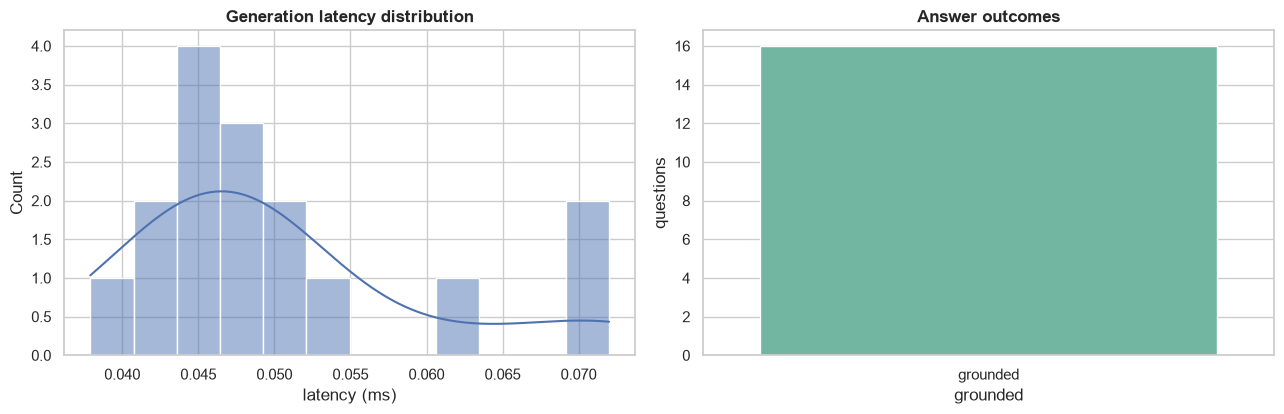

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
sns.histplot(profile.latency_ms, bins=12, kde=True, color="#4C72B0", ax=axes[0])
axes[0].set_title("Generation latency distribution", weight="bold")
axes[0].set_xlabel("latency (ms)")
grounded_counts = profile.grounded.map({True: "grounded", False: "refused"}).value_counts()
sns.barplot(x=grounded_counts.index, y=grounded_counts.values, hue=grounded_counts.index, palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Answer outcomes", weight="bold")
axes[1].set_ylabel("questions")
plt.tight_layout()
plt.show()

## Takeaways

- Grounding is enforced by **code, not hope**: citations are validated against
  the retrieved set and unverifiable answers are rejected before they ship.
- Refusal is first-class behaviour — the safe response to weak evidence, and a
  property we can measure (see notebook 04's refusal-correctness metric).
- Measuring latency and answer size per call is the seam where a local client
  becomes a budgeted, monitored production dependency.

Next — [`04_rag_evaluation`](04_rag_evaluation.ipynb) scores the full pipeline
and gates it like a CI job.